# 04 — Frequency-Aware Gated Temporal Fusion Transformer (FAG-TFT)
### Novel Architecture — Primary Model
> **Contribution 1:** Domain-informed hierarchical variable selection groups vibration bands by physical significance before TFT feature selection.
> **Contribution 2:** CNN-LSTM Autoencoder gating mechanism activates TFT only upon anomaly detection — enabling simultaneous known and unknown fault detection.
> Run 00_Data_Preparation.ipynb first.

In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import f1_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')

✅ Device: cpu


In [2]:
with open('prepared_data.pkl','rb') as f: d = pickle.load(f)
with open('encoder.pkl','rb') as f: encoder = pickle.load(f)

X_train = torch.FloatTensor(d['X_train_seq']).to(DEVICE)
X_test  = torch.FloatTensor(d['X_test_seq']).to(DEVICE)
y_train = torch.LongTensor(d['y_train_seq']).to(DEVICE)
y_test  = torch.LongTensor(d['y_test_seq']).to(DEVICE)
X_ae_train = torch.FloatTensor(d['X_ae_train']).to(DEVICE)
X_ae_test  = torch.FloatTensor(d['X_ae_test']).to(DEVICE)

NUM_CLASSES  = d['num_classes']
NUM_FEATURES = d['num_features']
TIME_STEPS   = d['TIME_STEPS']
feature_names = d['feature_names']

# Frequency group indices in the feature vector
G1_IDX  = list(range(0,  9))    # 10-100Hz  (9 bands)
G2_IDX  = list(range(9,  29))   # 100-300Hz (20 bands)
G3_IDX  = list(range(29, 60))   # 300-610Hz (31 bands)
EL_IDX  = list(range(60, 66))   # Electrical (6 features)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
ae_loader    = DataLoader(TensorDataset(X_ae_train, X_ae_train), batch_size=32, shuffle=True)
print(f'✅ Data loaded.')
print(f'   G1 (10-100Hz)  : {len(G1_IDX)} bands')
print(f'   G2 (100-300Hz) : {len(G2_IDX)} bands')
print(f'   G3 (300-610Hz) : {len(G3_IDX)} bands')
print(f'   Electrical     : {len(EL_IDX)} features')

✅ Data loaded.
   G1 (10-100Hz)  : 9 bands
   G2 (100-300Hz) : 20 bands
   G3 (300-610Hz) : 31 bands
   Electrical     : 6 features


---
## Stage 1 — CNN-LSTM Autoencoder (Anomaly Gate)
> Trained on healthy data only. Acts as the gate that decides whether the TFT classifier is activated.

In [3]:
class AnomalyGate(nn.Module):
    """
    CNN-LSTM Autoencoder trained on healthy data only.
    Reconstruction error = anomaly score.
    Low error  → healthy → TFT not activated.
    High error → anomaly → TFT activated for classification.
    """
    def __init__(self, time_steps, num_features, num_vib=60, num_elec=6):
        super().__init__()
        self.time_steps  = time_steps
        self.num_vib     = num_vib
        self.num_elec    = num_elec

        # Encoder
        self.enc_vib_conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.MaxPool1d(2)
        )
        enc_vib_size = 32 * (num_vib // 2)
        self.enc_lstm    = nn.LSTM(enc_vib_size + num_elec, 32, batch_first=True)
        self.bottleneck  = nn.Linear(32, 16)

        # Decoder
        self.dec_lstm    = nn.LSTM(16, 32, batch_first=True)
        self.dec_out     = nn.Linear(32, num_features)

    def encode(self, x):
        batch = x.size(0)
        vib_in  = x[:, :, :self.num_vib]
        elec_in = x[:, :, self.num_vib:]
        vib_feats = []
        for t in range(self.time_steps):
            vt = vib_in[:, t, :].unsqueeze(1)
            vt = self.enc_vib_conv(vt).view(batch, -1)
            vib_feats.append(vt)
        vib_seq  = torch.stack(vib_feats, dim=1)
        merged   = torch.cat([vib_seq, elec_in], dim=2)
        _, (h,_) = self.enc_lstm(merged)
        return self.bottleneck(h[-1])

    def forward(self, x):
        encoded  = self.encode(x)                          # (batch, 16)
        repeated = encoded.unsqueeze(1).repeat(1, self.time_steps, 1)
        dec_out, _ = self.dec_lstm(repeated)
        return self.dec_out(dec_out)                       # (batch, time_steps, num_features)

gate = AnomalyGate(TIME_STEPS, NUM_FEATURES).to(DEVICE)
print(f'AnomalyGate parameters: {sum(p.numel() for p in gate.parameters()):,}')

AnomalyGate parameters: 137,298


#### Train Anomaly Gate

Training Anomaly Gate on healthy data only...
Epoch   1 | Train: 0.939635 | Val: 0.880743
Epoch   2 | Train: 0.883603 | Val: 0.844907
Epoch   3 | Train: 0.848524 | Val: 0.822054
Epoch   4 | Train: 0.830763 | Val: 0.809130
Epoch   5 | Train: 0.814615 | Val: 0.789382
Epoch   6 | Train: 0.804967 | Val: 0.786621
Epoch   7 | Train: 0.797603 | Val: 0.781777
Epoch   8 | Train: 0.787546 | Val: 0.774506
Epoch   9 | Train: 0.775029 | Val: 0.757707
Epoch  10 | Train: 0.762505 | Val: 0.757810
Epoch  11 | Train: 0.753237 | Val: 0.739169
Epoch  12 | Train: 0.743537 | Val: 0.741725
Epoch  13 | Train: 0.737976 | Val: 0.738498
Epoch  14 | Train: 0.732208 | Val: 0.741159
Epoch  15 | Train: 0.726476 | Val: 0.733874
Epoch  16 | Train: 0.720325 | Val: 0.723645
Epoch  17 | Train: 0.710055 | Val: 0.717192
Epoch  18 | Train: 0.703472 | Val: 0.707610
Epoch  19 | Train: 0.694953 | Val: 0.693503
Epoch  20 | Train: 0.685047 | Val: 0.699912
Epoch  21 | Train: 0.679843 | Val: 0.689037
Epoch  22 | Train: 0.674568 | 

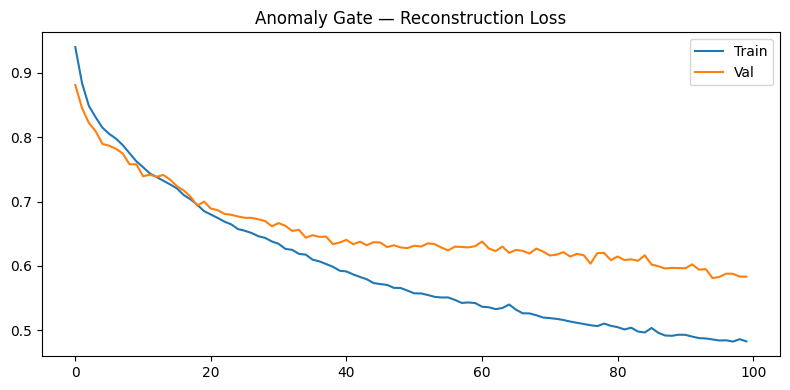

In [4]:
ae_optimizer = torch.optim.Adam(gate.parameters(), lr=1e-3)
ae_criterion = nn.MSELoss()
ae_best_loss = float('inf')
ae_patience  = 0
ae_losses, ae_val_losses = [], []

print('Training Anomaly Gate on healthy data only...')
for epoch in range(100):
    gate.train()
    batch_losses = []
    for xb, _ in ae_loader:
        ae_optimizer.zero_grad()
        loss = ae_criterion(gate(xb), xb)
        loss.backward()
        ae_optimizer.step()
        batch_losses.append(loss.item())

    gate.eval()
    with torch.no_grad():
        val_loss = ae_criterion(gate(X_ae_test), X_ae_test).item()
    ae_losses.append(np.mean(batch_losses))
    ae_val_losses.append(val_loss)

    if val_loss < ae_best_loss:
        ae_best_loss = val_loss
        torch.save(gate.state_dict(), 'best_anomaly_gate.pt')
        ae_patience = 0
    else:
        ae_patience += 1
        if ae_patience >= 15:
            print(f'Early stopping at epoch {epoch+1}')
            break

    if (epoch+1) % 1 == 0:
        print(f'Epoch {epoch+1:3d} | Train: {np.mean(batch_losses):.6f} | Val: {val_loss:.6f}')

plt.figure(figsize=(8,4))
plt.plot(ae_losses, label='Train')
plt.plot(ae_val_losses, label='Val')
plt.title('Anomaly Gate — Reconstruction Loss')
plt.legend()
plt.tight_layout()
plt.savefig('anomaly_gate_loss.png', dpi=150)
plt.show()

#### Compute Anomaly Thresholds

Reconstruction Error on Healthy Data:
  Mean : 0.491596
  p95  : 0.787259  ← warning threshold
  p99  : 0.924648  ← critical threshold


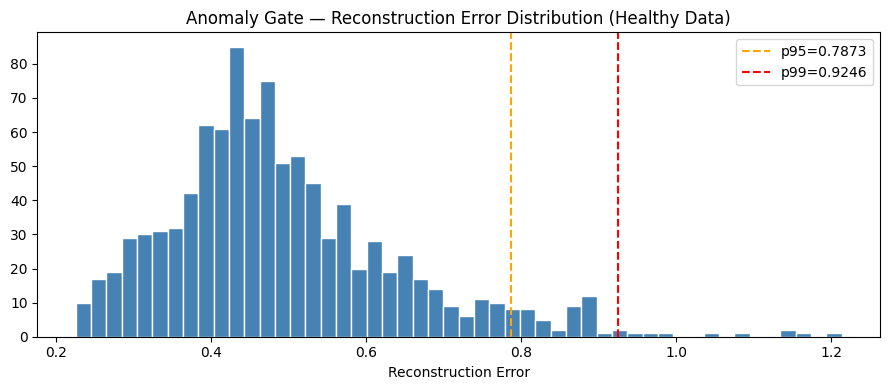

✅ Thresholds saved to ae_thresholds.pkl


In [5]:
gate.load_state_dict(torch.load('best_anomaly_gate.pt'))
gate.eval()

with torch.no_grad():
    recon = gate(X_ae_test)
    errors = torch.mean(torch.abs(X_ae_test - recon), dim=(1,2)).cpu().numpy()

WARNING_THRESHOLD  = float(np.percentile(errors, 95))
CRITICAL_THRESHOLD = float(np.percentile(errors, 99))

print(f'Reconstruction Error on Healthy Data:')
print(f'  Mean : {np.mean(errors):.6f}')
print(f'  p95  : {WARNING_THRESHOLD:.6f}  ← warning threshold')
print(f'  p99  : {CRITICAL_THRESHOLD:.6f}  ← critical threshold')

plt.figure(figsize=(9,4))
plt.hist(errors, bins=50, color='steelblue', edgecolor='white')
plt.axvline(WARNING_THRESHOLD,  color='orange', linestyle='--', label=f'p95={WARNING_THRESHOLD:.4f}')
plt.axvline(CRITICAL_THRESHOLD, color='red',    linestyle='--', label=f'p99={CRITICAL_THRESHOLD:.4f}')
plt.title('Anomaly Gate — Reconstruction Error Distribution (Healthy Data)')
plt.xlabel('Reconstruction Error')
plt.legend()
plt.tight_layout()
plt.savefig('anomaly_gate_thresholds.png', dpi=150)
plt.show()

thresholds = {'warning': WARNING_THRESHOLD, 'critical': CRITICAL_THRESHOLD}
with open('ae_thresholds.pkl','wb') as f: pickle.dump(thresholds, f)
print('✅ Thresholds saved to ae_thresholds.pkl')

---
## Stage 2 — Frequency-Aware TFT Classifier
### Novel Components:
1. **Gated Residual Network (GRN)** — core building block of TFT
2. **Hierarchical Variable Selection Network** — selects features within physical frequency groups
3. **Multi-Head Attention** — learns which past records are most relevant
4. **Quantile output** — provides uncertainty estimates

In [6]:
# ── GATED RESIDUAL NETWORK ───────────────────────────────────────────
class GRN(nn.Module):
    """
    Core TFT building block.
    Uses gating to selectively pass information — allows the model
    to skip components that are not useful for the current input.
    This is especially valuable with small datasets where
    over-parameterised paths would cause overfitting.
    """
    def __init__(self, input_size, hidden_size, output_size, dropout=0.1):
        super().__init__()
        self.fc1      = nn.Linear(input_size, hidden_size)
        self.fc2      = nn.Linear(hidden_size, output_size)
        self.gate_fc  = nn.Linear(hidden_size, output_size)
        self.elu      = nn.ELU()
        self.sigmoid  = nn.Sigmoid()
        self.dropout  = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(output_size)
        self.residual = nn.Linear(input_size, output_size) if input_size != output_size else nn.Identity()

    def forward(self, x):
        h = self.elu(self.fc1(x))
        h = self.dropout(h)
        gate = self.sigmoid(self.gate_fc(h))
        out  = gate * self.fc2(h)
        return self.layer_norm(out + self.residual(x))


# ── HIERARCHICAL VARIABLE SELECTION NETWORK ──────────────────────────
class HierarchicalVSN(nn.Module):
    """
    NOVEL CONTRIBUTION 1: Frequency-Aware Variable Selection.

    Standard TFT VSN treats all features equally.
    This VSN first selects within each physical frequency group,
    then selects across groups — matching the physical structure
    of vibration data from industrial sewing machines.

    Group 1: 10-100Hz  → mechanical imbalance signals
    Group 2: 100-300Hz → bearing wear signals
    Group 3: 300-610Hz → blade/cutting signals
    Group 4: Electrical → voltage/current signals
    """
    def __init__(self, g1_size, g2_size, g3_size, el_size, hidden_size, dropout=0.1):
        super().__init__()
        # Within-group selection
        self.grn_g1 = GRN(g1_size, hidden_size, hidden_size, dropout)
        self.grn_g2 = GRN(g2_size, hidden_size, hidden_size, dropout)
        self.grn_g3 = GRN(g3_size, hidden_size, hidden_size, dropout)
        self.grn_el = GRN(el_size, hidden_size, hidden_size, dropout)

        # Within-group importance weights
        self.sel_g1 = nn.Linear(hidden_size, hidden_size)
        self.sel_g2 = nn.Linear(hidden_size, hidden_size)
        self.sel_g3 = nn.Linear(hidden_size, hidden_size)
        self.sel_el = nn.Linear(hidden_size, hidden_size)

        # Across-group selection
        self.across_grn  = GRN(hidden_size * 4, hidden_size, 4, dropout)
        self.group_merge = nn.Linear(hidden_size * 4, hidden_size)

    def forward(self, x_g1, x_g2, x_g3, x_el):
        # Within-group feature extraction
        h1 = self.grn_g1(x_g1)    # (batch, hidden)
        h2 = self.grn_g2(x_g2)
        h3 = self.grn_g3(x_g3)
        he = self.grn_el(x_el)

        # Within-group importance gating
        w1 = torch.sigmoid(self.sel_g1(h1))
        w2 = torch.sigmoid(self.sel_g2(h2))
        w3 = torch.sigmoid(self.sel_g3(h3))
        we = torch.sigmoid(self.sel_el(he))

        h1, h2, h3, he = w1*h1, w2*h2, w3*h3, we*he

        # Across-group selection — which physical group matters most?
        concat   = torch.cat([h1, h2, h3, he], dim=-1)   # (batch, hidden*4)
        g_weights = F.softmax(self.across_grn(concat), dim=-1)  # (batch, 4)

        # Store for interpretability
        self.group_weights = g_weights.detach().cpu()

        # Weighted merge
        merged = (g_weights[:,0:1]*h1 + g_weights[:,1:2]*h2 +
                  g_weights[:,2:3]*h3 + g_weights[:,3:4]*he)
        return self.group_merge(concat) + merged


# ── FAG-TFT CLASSIFIER ────────────────────────────────────────────────
class FAG_TFT(nn.Module):
    """
    Frequency-Aware Gated Temporal Fusion Transformer.

    Architecture:
    1. HierarchicalVSN processes each timestep by frequency group
    2. LSTM encoder learns local temporal patterns
    3. Multi-Head Attention learns which past records are most relevant
    4. GRN + classifier head produces breakdown classification
    """
    def __init__(self, g1_size, g2_size, g3_size, el_size,
                 time_steps, num_classes, hidden_size=64, num_heads=4, dropout=0.1):
        super().__init__()
        self.time_steps  = time_steps
        self.g1_size     = g1_size
        self.g2_size     = g2_size
        self.g3_size     = g3_size
        self.el_size     = el_size

        # Per-timestep hierarchical variable selection
        self.vsn = HierarchicalVSN(g1_size, g2_size, g3_size, el_size, hidden_size, dropout)

        # LSTM encoder
        self.lstm_encoder = nn.LSTM(hidden_size, hidden_size, 2,
                                    batch_first=True, dropout=dropout)

        # Multi-Head Self-Attention
        self.attention = nn.MultiheadAttention(hidden_size, num_heads,
                                               dropout=dropout, batch_first=True)
        self.attn_norm = nn.LayerNorm(hidden_size)

        # Post-attention GRN
        self.post_attn_grn = GRN(hidden_size, hidden_size, hidden_size, dropout)

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        # x: (batch, time_steps, 66)
        batch = x.size(0)

        # Split into frequency groups per timestep
        vsn_out = []
        for t in range(self.time_steps):
            xt = x[:, t, :]
            g1 = xt[:, :self.g1_size]
            g2 = xt[:, self.g1_size:self.g1_size+self.g2_size]
            g3 = xt[:, self.g1_size+self.g2_size:self.g1_size+self.g2_size+self.g3_size]
            el = xt[:, self.g1_size+self.g2_size+self.g3_size:]
            vsn_out.append(self.vsn(g1, g2, g3, el))
        vsn_seq = torch.stack(vsn_out, dim=1)             # (batch, time_steps, hidden)

        # LSTM encoder
        lstm_out, _ = self.lstm_encoder(vsn_seq)          # (batch, time_steps, hidden)

        # Multi-Head Self-Attention
        attn_out, self.attn_weights = self.attention(lstm_out, lstm_out, lstm_out)
        attn_out = self.attn_norm(attn_out + lstm_out)    # residual

        # Use last timestep for classification
        out = self.post_attn_grn(attn_out[:, -1, :])
        return self.classifier(out)

    def get_group_importance(self):
        """Returns average importance weight per frequency group — for thesis interpretability plot."""
        return self.vsn.group_weights.mean(dim=0).numpy()


tft_model = FAG_TFT(
    g1_size=len(G1_IDX), g2_size=len(G2_IDX),
    g3_size=len(G3_IDX), el_size=len(EL_IDX),
    time_steps=TIME_STEPS, num_classes=NUM_CLASSES,
    hidden_size=64, num_heads=4
).to(DEVICE)

print(f'FAG-TFT parameters: {sum(p.numel() for p in tft_model.parameters()):,}')

FAG-TFT parameters: 192,025


#### Train FAG-TFT Classifier

Epoch   1 | Train: 0.4619 | Val: 0.3902
Epoch   2 | Train: 0.3945 | Val: 0.3885
Epoch   3 | Train: 0.3929 | Val: 0.3884
Epoch   4 | Train: 0.3966 | Val: 0.3902
Epoch   5 | Train: 0.3893 | Val: 0.3917
Epoch   6 | Train: 0.3819 | Val: 0.4074
Epoch   7 | Train: 0.3782 | Val: 0.4065
Epoch   8 | Train: 0.3731 | Val: 0.4177
Epoch   9 | Train: 0.3699 | Val: 0.4078
Epoch  10 | Train: 0.3497 | Val: 0.4151
Epoch  11 | Train: 0.3387 | Val: 0.4383
Epoch  12 | Train: 0.3219 | Val: 0.4495
Epoch  13 | Train: 0.3044 | Val: 0.4546
Epoch  14 | Train: 0.2981 | Val: 0.4705
Epoch  15 | Train: 0.2701 | Val: 0.5133
Epoch  16 | Train: 0.2568 | Val: 0.5276
Epoch  17 | Train: 0.2332 | Val: 0.5371
Epoch  18 | Train: 0.2168 | Val: 0.5539
Epoch  19 | Train: 0.1929 | Val: 0.5947
Epoch  20 | Train: 0.1754 | Val: 0.6087
Epoch  21 | Train: 0.1584 | Val: 0.6441
Epoch  22 | Train: 0.1475 | Val: 0.6550
Early stopping at epoch 23


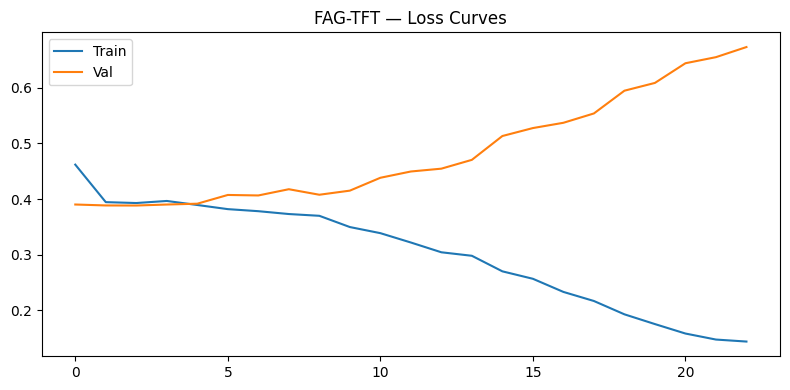

In [7]:
EPOCHS    = 100
optimizer = torch.optim.Adam(tft_model.parameters(), lr=5e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

best_val_loss = float('inf')
patience_counter = 0
PATIENCE = 20
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    tft_model.train()
    batch_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(tft_model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(tft_model.parameters(), 1.0)
        optimizer.step()
        batch_losses.append(loss.item())
    scheduler.step()

    tft_model.eval()
    with torch.no_grad():
        val_loss = criterion(tft_model(X_test), y_test).item()
    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(tft_model.state_dict(), 'best_fag_tft.pt')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

    if (epoch+1) % 1 == 0:
        print(f'Epoch {epoch+1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}')

plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Val')
plt.title('FAG-TFT — Loss Curves')
plt.legend()
plt.tight_layout()
plt.savefig('fag_tft_loss.png', dpi=150)
plt.show()

#### Evaluate FAG-TFT

FAG-TFT RESULTS
Accuracy : 92.04%
F1 Score : 0.8823
RMSE     : 0.5439
MAE      : 0.1386

                    precision    recall  f1-score   support

       Blade Blunt       0.00      0.00      0.00        21
           Healthy       0.92      1.00      0.96       983
High Foot Pressure       0.00      0.00      0.00        22
Skip Stitches/Slip       0.00      0.00      0.00        21
          Waveness       0.00      0.00      0.00        21

          accuracy                           0.92      1068
         macro avg       0.18      0.20      0.19      1068
      weighted avg       0.85      0.92      0.88      1068



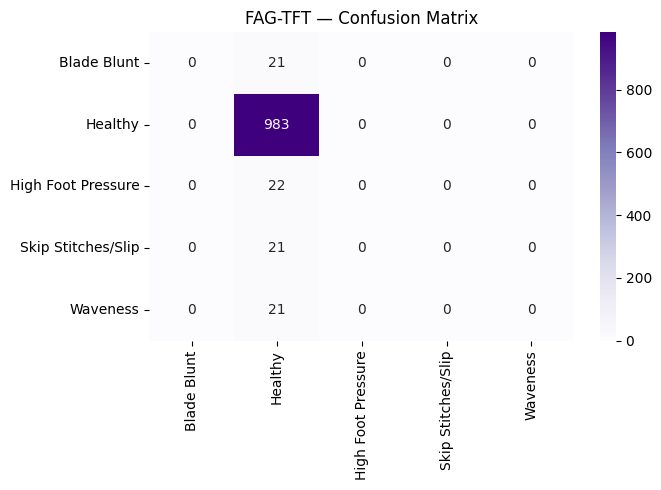

In [8]:
tft_model.load_state_dict(torch.load('best_fag_tft.pt'))
tft_model.eval()
with torch.no_grad():
    logits = tft_model(X_test)
    probs  = torch.softmax(logits, dim=1).cpu().numpy()
    y_pred = np.argmax(probs, axis=1)
    y_true = y_test.cpu().numpy()

acc  = accuracy_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred, average='weighted')
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)

print('='*50)
print('FAG-TFT RESULTS')
print('='*50)
print(f'Accuracy : {acc*100:.2f}%')
print(f'F1 Score : {f1:.4f}')
print(f'RMSE     : {rmse:.4f}')
print(f'MAE      : {mae:.4f}')
print()
print(classification_report(y_true, y_pred, target_names=encoder.classes_))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('FAG-TFT — Confusion Matrix')
plt.tight_layout()
plt.savefig('fag_tft_confusion.png', dpi=150)
plt.show()

#### Interpretability — Group Importance Weights
> This is your key thesis plot showing WHICH frequency group the model focuses on for each breakdown type.

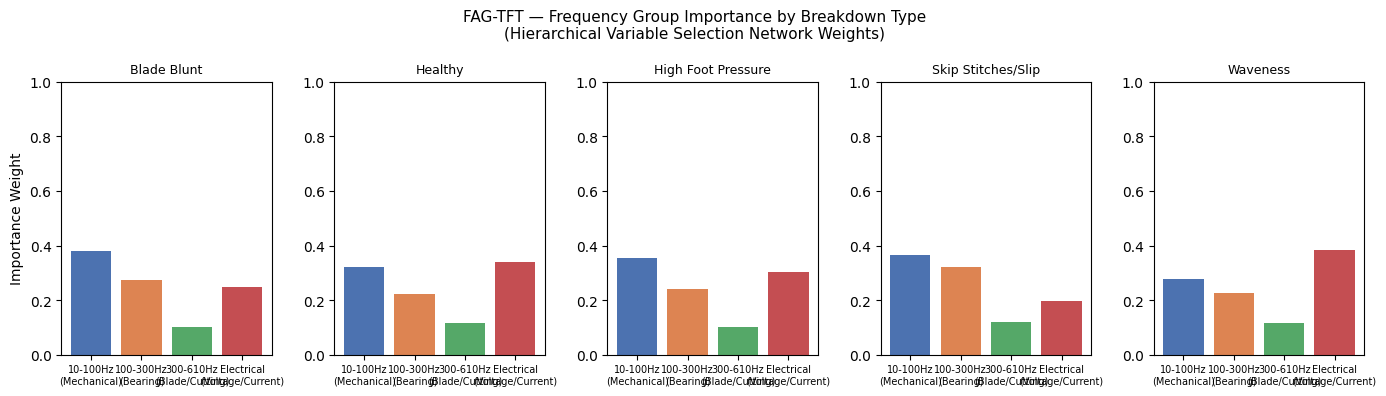

✅ Group importance plot saved — use this in your thesis.


In [9]:
group_names  = ['10-100Hz\n(Mechanical)', '100-300Hz\n(Bearing)',
                '300-610Hz\n(Blade/Cutting)', 'Electrical\n(Voltage/Current)']
colors       = ['#4C72B0','#DD8452','#55A868','#C44E52']

# Get per-class group importance
class_importances = {cls: np.zeros(4) for cls in encoder.classes_}
class_counts = {cls: 0 for cls in encoder.classes_}

tft_model.eval()
with torch.no_grad():
    for i in range(0, len(X_test), 32):
        xb = X_test[i:i+32]
        _  = tft_model(xb)
        gw = tft_model.vsn.group_weights.numpy()  # (batch, 4)
        yb = y_true[i:i+len(xb)]
        for j, cls_idx in enumerate(yb):
            cls_name = encoder.classes_[cls_idx]
            class_importances[cls_name] += gw[j]
            class_counts[cls_name] += 1

for cls in encoder.classes_:
    if class_counts[cls] > 0:
        class_importances[cls] /= class_counts[cls]

fig, axes = plt.subplots(1, len(encoder.classes_), figsize=(14, 4))
for idx, cls in enumerate(encoder.classes_):
    axes[idx].bar(group_names, class_importances[cls], color=colors)
    axes[idx].set_title(cls, fontsize=9)
    axes[idx].set_ylim(0, 1)
    axes[idx].set_ylabel('Importance Weight' if idx==0 else '')
    axes[idx].tick_params(axis='x', labelsize=7)

plt.suptitle('FAG-TFT — Frequency Group Importance by Breakdown Type\n(Hierarchical Variable Selection Network Weights)',
             fontsize=11)
plt.tight_layout()
plt.savefig('fag_tft_group_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Group importance plot saved — use this in your thesis.')

#### Save All Artifacts

In [10]:
tft_results = {'model':'FAG-TFT','accuracy':acc,'f1':f1,'rmse':rmse,'mae':mae}
with open('fag_tft_results.pkl','wb') as f: pickle.dump(tft_results, f)

# Save TFT config for Live Analyser
tft_config = {
    'g1_size'     : len(G1_IDX),
    'g2_size'     : len(G2_IDX),
    'g3_size'     : len(G3_IDX),
    'el_size'     : len(EL_IDX),
    'time_steps'  : TIME_STEPS,
    'num_classes' : NUM_CLASSES,
    'hidden_size' : 64,
    'num_heads'   : 4,
    'G1_IDX'      : G1_IDX,
    'G2_IDX'      : G2_IDX,
    'G3_IDX'      : G3_IDX,
    'EL_IDX'      : EL_IDX,
}
with open('tft_config.pkl','wb') as f: pickle.dump(tft_config, f)

print('✅ Saved:')
print('   best_anomaly_gate.pt')
print('   best_fag_tft.pt')
print('   ae_thresholds.pkl')
print('   fag_tft_results.pkl')
print('   tft_config.pkl')
print(f'\nFinal FAG-TFT Accuracy: {acc*100:.2f}%')

✅ Saved:
   best_anomaly_gate.pt
   best_fag_tft.pt
   ae_thresholds.pkl
   fag_tft_results.pkl
   tft_config.pkl

Final FAG-TFT Accuracy: 92.04%
